# 04 — CTS-R Evaluation: Base vs. Fine-Tuned Qwen3.5-9B

Evaluates the SFT model against the base Qwen3.5-9B using a **simulated clinical interview** paradigm:

1. **Patient simulator** — a Groq-hosted LLM plays one of three detailed clinical vignettes (Marcus, Priya, Robert) turn-by-turn.
2. **Therapist** — the model under evaluation (base or SFT) generates responses; `<think>` blocks are stripped before the patient sees them.
3. **LLM-as-judge** — a second Groq call scores the full transcript on all **12 CTS-R items** (0–6 Likert scale), producing an objective per-axis profile.
4. **Results** are aggregated into a grouped bar chart and saved as JSONL + CSV.

> Rubric: Blackburn et al. (2001) *Cognitive Therapy Scale – Revised (CTS-R)*


In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

import json
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from groq import Groq
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch : 2.12.0+cu130
CUDA    : True
GPU     : NVIDIA RTX 6000 Ada Generation
VRAM    : 50.9 GB


## Configuration


In [2]:
# ── Therapist models ──────────────────────────────────────────────────────────
BASE_MODEL_NAME = "Qwen/Qwen3.5-9B"

SSD_ROOT        = Path(os.environ.get("SSD_ROOT", "/tmp"))
SFT_MODEL_PATH  = SSD_ROOT / "models/qwen3.5-sft-new/lora-adapters"

# ── Groq patient / judge model ────────────────────────────────────────────────
PATIENT_MODEL = "openai/gpt-oss-120b"
JUDGE_MODEL   = "openai/gpt-oss-120b"

# ── Conversation ─────────────────────────────────────────────────────────────
MAX_TURNS             = 6    # full therapist-patient exchanges per session
THERAPIST_MAX_TOKENS  = 1200
PATIENT_MAX_TOKENS    = 200
JUDGE_MAX_TOKENS      = 3000  # one sentence + score per item × 12 items
GROQ_CALL_DELAY       = 0.6  # seconds between Groq calls (rate-limit headroom)

# ── Output ────────────────────────────────────────────────────────────────────
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_JSONL  = REPORTS_DIR / "ctsr_eval_transcripts.jsonl"
EVAL_CSV    = REPORTS_DIR / "ctsr_eval_scores.csv"
CHART_PNG   = REPORTS_DIR / "ctsr_eval_chart.png"

# ── Therapist system prompt (shared by base and SFT) ─────────────────────────
THERAPIST_SYSTEM = (
    "You are a skilled CBT (Cognitive Behavioural Therapy) therapist conducting an initial "
    "clinical assessment session. Follow CBT principles:\n"
    "- Open with a collaborative agenda-setting check-in\n"
    "- Use Socratic questioning to explore thoughts, feelings, and behaviours\n"
    "- Help the patient identify links between cognitions, emotions, and behaviours\n"
    "- Validate emotions while gently challenging unhelpful thought patterns\n"
    "- Work toward a shared conceptualisation and practical goal-oriented interventions\n"
    "- Be warm, empathic, genuine, and professionally boundaried\n"
    "- Propose appropriate between-session homework toward the end of the session\n\n"
    "Respond as a therapist — ask thoughtful questions, reflect back, guide toward insight. "
    "Keep responses focused (2–4 sentences)."
)

print(f"Base model : {BASE_MODEL_NAME}")
print(f"SFT model  : {SFT_MODEL_PATH}")
print(f"Patient    : {PATIENT_MODEL}")
print(f"Reports    : {REPORTS_DIR.resolve()}")

Base model : Qwen/Qwen3.5-9B
SFT model  : /data_1_8TB_ssd/kevint/models/qwen3.5-sft-new/lora-adapters
Patient    : openai/gpt-oss-120b
Reports    : /home/kevint/cse-reu/reports


## Clinical Vignettes

Three detailed patient personas that the Groq patient simulator will embody:
- **Marcus** — 52-year-old man, recently laid off, depression
- **Priya** — 28-year-old engineer, generalised anxiety, perfectionism
- **Robert** — 67-year-old retired officer, grief, resistant/minimising


In [3]:
VIGNETTES = [
    {
        "name": "Marcus",
        "background": (
            "Marcus is a 52-year-old man who was recently laid off from his manufacturing management "
            "job after 24 years. He presents with low mood, anhedonia, sleep difficulties, and a sense "
            "of worthlessness tied to his identity as a provider and leader. He ruminates: "
            "'I'll never find work at my age', 'I've let my family down'. "
            "Mild to moderate depression. No suicidal ideation."
        ),
        "system_prompt": (
            "You are Marcus, a 52-year-old man attending your third CBT session. "
            "You were laid off from a manufacturing management job three months ago after 24 years — "
            "your whole identity was tied to being a provider and leader. You feel ashamed and worthless. "
            "You struggle to get out of bed, have lost interest in woodworking and football, sleep poorly, "
            "and frequently ruminate: 'I'll never find work at my age', 'I've let my family down'. "
            "You're somewhat guarded at first but open up if the therapist is empathic and doesn't push too hard. "
            "You speak plainly and practically; you don't use clinical language. "
            "Respond naturally as Marcus. Keep responses 2–5 sentences. Never mention therapy techniques."
        ),
    },
    {
        "name": "Priya",
        "background": (
            "Priya is a 28-year-old software engineer with generalised anxiety. She is a high achiever "
            "who worries constantly about performance, making mistakes, and peer judgement. She engages in "
            "perfectionism, over-preparation, and avoidance of delegation. She is articulate and insightful "
            "but struggles with uncertainty and tends to intellectualise. "
            "Key beliefs: 'If I make one mistake, my credibility is gone', 'I need to stay in control to be safe'."
        ),
        "system_prompt": (
            "You are Priya, a 28-year-old software engineer attending your third CBT session. "
            "You have generalised anxiety — you worry constantly about making mistakes at work, "
            "what colleagues think of you, and whether you're performing well enough. "
            "You spend hours double-checking code and cannot delegate tasks. "
            "You're intelligent and self-aware: you know some of your worry is irrational, but you can't stop it. "
            "You have muscle tension, difficulty concentrating, and occasional pre-meeting panic. "
            "Key thoughts: 'If I make one mistake my credibility is gone', 'I need to be in control to be safe'. "
            "You engage well with therapy but tend to intellectualise and want concrete solutions. "
            "Respond naturally as Priya. Keep responses 2–5 sentences. Never mention therapy techniques."
        ),
    },
    {
        "name": "Robert",
        "background": (
            "Robert is a 67-year-old retired police officer referred by his GP following his wife's death "
            "18 months ago. He presents with low mood, irritability, and social withdrawal. "
            "He minimises symptoms, is sceptical of therapy, and frames emotional distress as weakness. "
            "He is guarded and resistant to emotional exploration but responds to structure and competence."
        ),
        "system_prompt": (
            "You are Robert, a 67-year-old retired police officer attending your third CBT session. "
            "Your wife died 18 months ago after a long illness. Since then you've become more isolated — "
            "you don't see old friends, you've stopped going to the golf club, and you feel irritable most of the time. "
            "You came to therapy because your GP insisted; you're sceptical: 'I've dealt with far worse than this'. "
            "You dislike talking about feelings and deflect with blunt humour or minimisation ('I'm fine, just tired'). "
            "You respect competence and directness — if the therapist is structured and doesn't push too hard, "
            "you warm up slightly. Key thoughts: 'Needing help is weakness', 'She's gone, nothing to do about it', "
            "'I should be over this by now'. "
            "Respond naturally as Robert. Keep responses 2–5 sentences. Never mention therapy techniques."
        ),
    },
]

print(f"Vignettes loaded: {[v['name'] for v in VIGNETTES]}")


Vignettes loaded: ['Marcus', 'Priya', 'Robert']


## CTS-R Rubric — 12 Items, 0–6 Scale

Full Cognitive Therapy Scale – Revised (Blackburn et al., 2001).  
Scale anchors: **0** = absence/highly inappropriate · **3** = competent with some problems · **6** = excellent / expert


In [4]:
CTSR_ITEMS = [
    {
        "number": 1,
        "name": "Agenda Setting & Adherence",
        "key": "item_1_agenda_setting",
        "short_label": "Agenda\nSetting",
        "key_features": (
            "Explicit, agreed, prioritised, and feasible agenda set collaboratively; "
            "includes homework review; therapist adheres to agreed agenda throughout."
        ),
        "anchors": {
            0: "No agenda set, or highly inappropriate; agenda not adhered to.",
            1: "Inappropriate agenda (no focus, unrealistic, homework not reviewed).",
            2: "Attempt at agenda made but major difficulties (e.g. unilaterally set); poor adherence.",
            3: "Appropriate agenda set but some difficulties (e.g. poor collaboration); some adherence.",
            4: "Appropriate agenda, minor difficulties (e.g. no prioritisation); moderate adherence.",
            5: "Discrete prioritised agenda set, reviewed at end; adhered to; minimal problems.",
            6: "Excellent agenda, or highly effective in the face of patient difficulties.",
        },
    },
    {
        "number": 2,
        "name": "Feedback",
        "key": "item_2_feedback",
        "short_label": "Feedback",
        "key_features": (
            "Two-way feedback via summaries (start/end) and chunking throughout; "
            "appropriate content; effectively delivered and elicited."
        ),
        "anchors": {
            0: "Absence of feedback or highly inappropriate.",
            1: "Minimal appropriate feedback.",
            2: "Appropriate feedback but not frequent enough; vague.",
            3: "Appropriate feedback given and elicited frequently; some difficulties in content or delivery.",
            4: "Appropriate, frequent feedback facilitating moderate gains; minor inconsistencies.",
            5: "Highly appropriate, regular feedback enabling significant therapeutic gains; minimal problems.",
            6: "Excellent feedback, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 3,
        "name": "Collaboration",
        "key": "item_3_collaboration",
        "short_label": "Collaboration",
        "key_features": (
            "Patient actively encouraged to participate; productive teamwork; "
            "shared problem solving and decision making; therapist neither dominating nor passive; "
            "written summaries shared where appropriate."
        ),
        "anchors": {
            0: "Patient actively prevented or discouraged from being collaborative.",
            1: "Therapist too controlling, dominating, or passive.",
            2: "Occasional collaboration; didactic style encourages patient passivity.",
            3: "Teamwork evident but some problems (e.g. insufficient time for patient reflection).",
            4: "Effective teamwork but not consistent; minor problems.",
            5: "Effective teamwork throughout, verbal and written; minimal problems.",
            6: "Excellent teamwork, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 4,
        "name": "Pacing & Efficient Use of Time",
        "key": "item_4_pacing",
        "short_label": "Pacing",
        "key_features": (
            "Session flows through discrete start, middle, and end phases; "
            "well paced for patient needs; unproductive digressions handled smoothly; "
            "session does not overrun."
        ),
        "anchors": {
            0: "Poor time management leading to aimless or overly rigid session.",
            1: "Session too slow or too fast for patient's needs.",
            2: "Reasonable pacing but digressions/repetition lead to inefficient use of time.",
            3: "Good pacing some of the time; diffuse at times.",
            4: "Balanced allocation with discrete phases; minor problems.",
            5: "Good time management; session running smoothly; minimal problems.",
            6: "Excellent time management, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 5,
        "name": "Interpersonal Effectiveness",
        "key": "item_5_interpersonal_effectiveness",
        "short_label": "Interpersonal\nEffect.",
        "key_features": (
            "Core conditions present: warmth, genuineness, and empathy; "
            "patient put at ease; therapist enters patient's feelings imaginatively to promote change; "
            "professional boundaries maintained."
        ),
        "anchors": {
            0: "Therapist's manner makes patient disengage, distrustful, or hostile.",
            1: "Difficulty showing empathy, genuineness, and warmth.",
            2: "Therapist's style (e.g. intellectualisation) at times impedes empathic understanding.",
            3: "Understands explicit meanings; some trust developing; some inconsistency.",
            4: "Understands implicit and explicit meanings; demonstrates in manner; minor problems.",
            5: "Very good interpersonal effectiveness; patient confident in being understood; minimal problems.",
            6: "Excellent, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 6,
        "name": "Eliciting Appropriate Emotional Expression",
        "key": "item_6_emotional_expression",
        "short_label": "Emotional\nExpression",
        "key_features": (
            "Facilitates appropriate emotional processing (neither too high nor too low); "
            "accesses range of emotions; appropriate containment and differentiation of emotions; "
            "deals with interfering emotions (hostility, excessive anger)."
        ),
        "anchors": {
            0: "Patient under- or over-stimulated; feelings ignored/dismissed or unmanageable.",
            1: "Failure to facilitate access and expression of appropriate emotions.",
            2: "Some facilitation evident but many relevant opportunities missed.",
            3: "Some effective facilitation; patient slightly more aware of emotions.",
            4: "Effective facilitation; patient more aware of relevant emotions; minor problems.",
            5: "Very effective facilitation; optimal arousal; good differentiation; minimal problems.",
            6: "Excellent, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 7,
        "name": "Eliciting Key Cognitions",
        "key": "item_7_eliciting_cognitions",
        "short_label": "Elicit\nCognitions",
        "key_features": (
            "Elicits cognitions (thoughts, assumptions, core beliefs) linked to distress; "
            "selects key/hot thoughts; uses Socratic questioning, monitoring, downward arrowing, imagery; "
            "appropriate depth for stage of therapy."
        ),
        "anchors": {
            0: "Therapist fails to elicit relevant cognitions.",
            1: "Inappropriate cognitions selected or key cognitions ignored.",
            2: "Some cognitions elicited but link to emotions not made clear.",
            3: "Key cognition(s) elicited competently; some problems evident.",
            4: "Cognitions/emotions elicited in verbal or written form leading to new understanding; minor problems.",
            5: "Effective eliciting and selection of cognitions; generally dealt with appropriately; minimal problems.",
            6: "Excellent work on key cognitions and emotions, or very good in the face of difficulties.",
        },
    },
    {
        "number": 8,
        "name": "Eliciting Behaviours",
        "key": "item_8_eliciting_behaviours",
        "short_label": "Elicit\nBehaviours",
        "key_features": (
            "Elicits behaviours (including safety-seeking) linked to distress; "
            "links behaviours to emotions; uses Socratic questioning, monitoring, imagery, role-play."
        ),
        "anchors": {
            0: "Therapist fails to elicit relevant behaviours.",
            1: "Inappropriate behaviours focused on.",
            2: "Some behaviours elicited but links to emotions not made clear.",
            3: "Behaviours/emotions elicited competently; some problems.",
            4: "Behaviours/emotions elicited leading to new understanding of their maintenance role; minor problems.",
            5: "Effective eliciting and selection; generally dealt with appropriately; minimal problems.",
            6: "Excellent work on behaviours and emotions, or very good in the face of difficulties.",
        },
    },
    {
        "number": 9,
        "name": "Guided Discovery",
        "key": "item_9_guided_discovery",
        "short_label": "Guided\nDiscovery",
        "key_features": (
            "Patient helped to develop hypotheses and generate solutions; "
            "therapist style is open and inquisitive; effective Socratic questioning; "
            "creates doubt where certainty existed, enabling re-evaluation."
        ),
        "anchors": {
            0: "No attempt at guided discovery; hectoring and lecturing.",
            1: "Little opportunity for discovery; persuasion and debate excessive.",
            2: "Minimal discovery; some questioning but unhelpful in accessing thoughts/emotions.",
            3: "Some reflection; therapist follows productive line of discovery.",
            4: "Moderate discovery; questioning with skill leading to some synthesis; minor problems.",
            5: "Effective reflection; skilful Socratic questioning leading to discovery and synthesis; minimal problems.",
            6: "Excellent guided discovery; deep understanding developed, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 10,
        "name": "Conceptual Integration",
        "key": "item_10_conceptual_integration",
        "short_label": "Conceptual\nInteg.",
        "key_features": (
            "Appropriate CBT conceptualisation links history, triggers, and maintenance factors; "
            "used as platform for interventions and homework; "
            "integrates perceptions, beliefs, attitudes, and coping strategies."
        ),
        "anchors": {
            0: "Absence of an appropriate conceptualisation.",
            1: "Lack or misapplication of conceptualisation; aimless interventions.",
            2: "Rudimentary conceptualisation; not well integrated with goals.",
            3: "Conceptualisation partially developed; some integration; leads to coherent interventions.",
            4: "Moderately developed and integrated; minor problems.",
            5: "Very well developed and integrated; credible cognitive understanding; major therapeutic shifts; minimal problems.",
            6: "Excellent development and integration, or highly effective in the face of difficulties.",
        },
    },
    {
        "number": 11,
        "name": "Application of Change Methods",
        "key": "item_11_change_methods",
        "short_label": "Change\nMethods",
        "key_features": (
            "Appropriate range of cognitive methods (thought records, continua, imagery restructuring, "
            "pros/cons, examining alternatives, responsibility charts) and behavioural methods "
            "(behavioural experiments, graded tasks, role-play, applied relaxation); "
            "skill and flexibility in application; methods suited to patient."
        ),
        "anchors": {
            0: "Fails to use or misuses cognitive/behavioural methods.",
            1: "Insufficient or inappropriate methods; limited skill.",
            2: "Appropriate methods but major difficulties evident.",
            3: "Number of methods applied competently; some problems (e.g. incomplete).",
            4: "Range of methods applied with skill and flexibility; new perspectives; minor problems.",
            5: "Systematically applies appropriate range in creative and effective manner; minimal problems.",
            6: "Excellent range and application, or successful application in the face of difficulties.",
        },
    },
    {
        "number": 12,
        "name": "Homework Setting",
        "key": "item_12_homework_setting",
        "short_label": "Homework\nSetting",
        "key_features": (
            "Appropriate homework with clear, precise goals; derived from session material; "
            "jointly negotiated; rationale explained; potential obstacles explored."
        ),
        "anchors": {
            0: "Fails to set homework or sets inappropriate homework.",
            1: "Homework not negotiated; insufficient time; ineffectual task.",
            2: "Homework set unilaterally and routinely; no rationale explained.",
            3: "Appropriate task set but problems (e.g. not explained, not jointly developed).",
            4: "Appropriate homework jointly negotiated with clear goals/rationale; minor problems.",
            5: "Appropriate homework, jointly negotiated, well explained, obstacles explored; minimal problems.",
            6: "Excellent homework, or highly appropriate in the face of difficulties.",
        },
    },
]

ITEM_KEYS   = [it["key"]         for it in CTSR_ITEMS]
ITEM_LABELS = [it["short_label"] for it in CTSR_ITEMS]

print(f"CTS-R items loaded: {len(CTSR_ITEMS)}")
for it in CTSR_ITEMS:
    print(f"  {it['number']:>2}. {it['name']}")


CTS-R items loaded: 12
   1. Agenda Setting & Adherence
   2. Feedback
   3. Collaboration
   4. Pacing & Efficient Use of Time
   5. Interpersonal Effectiveness
   6. Eliciting Appropriate Emotional Expression
   7. Eliciting Key Cognitions
   8. Eliciting Behaviours
   9. Guided Discovery
  10. Conceptual Integration
  11. Application of Change Methods
  12. Homework Setting


## Groq Client


In [5]:
groq_client = Groq(api_key=os.environ["GROQ_API_KEY"])
print("Groq client initialised.")


Groq client initialised.


## Conversation Engine

Core utilities:
- `strip_thinking` — removes Qwen3 `<think>…</think>` chain-of-thought before the patient sees the reply
- `to_hf_messages` / `to_groq_messages` — convert shared turn list into the correct role mapping for each model
- `patient_turn` — calls Groq to get the patient's next utterance
- `therapist_turn` — runs the local HuggingFace model and strips CoT
- `run_interview` — orchestrates a full session


In [6]:
def strip_thinking(text: str) -> str:
    """Strip Qwen3 <think>...</think> chain-of-thought blocks from model output."""
    cleaned = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    return cleaned.strip()


def to_hf_messages(turns: list[dict], system_prompt: str) -> list[dict]:
    """
    Convert shared turn list to HuggingFace chat format from the therapist's POV.
      patient  → user
      therapist → assistant
    """
    messages = [{"role": "system", "content": system_prompt}]
    for t in turns:
        role = "user" if t["role"] == "patient" else "assistant"
        messages.append({"role": role, "content": t["content"]})
    return messages


def to_groq_messages(turns: list[dict], system_prompt: str) -> list[dict]:
    """
    Convert shared turn list to Groq chat format from the patient's POV.
      therapist → user
      patient   → assistant
    """
    messages = [{"role": "system", "content": system_prompt}]
    for t in turns:
        role = "user" if t["role"] == "therapist" else "assistant"
        messages.append({"role": role, "content": t["content"]})
    return messages


def patient_turn(client: Groq, vignette: dict, turns: list[dict]) -> str:
    """Generate the patient's next utterance via Groq."""
    messages = to_groq_messages(turns, vignette["system_prompt"])
    resp = client.chat.completions.create(
        model=PATIENT_MODEL,
        messages=messages,
        max_tokens=PATIENT_MAX_TOKENS,
        temperature=0.85,
    )
    time.sleep(GROQ_CALL_DELAY)
    return resp.choices[0].message.content.strip()


def therapist_turn(model, tokenizer, turns: list[dict]) -> str:
    """
    Generate the therapist's next utterance from the local HuggingFace model.
    Chain-of-thought (<think>…</think>) is stripped before returning.
    """
    messages = to_hf_messages(turns, THERAPIST_SYSTEM)

    # Qwen3's chat template requires at least one user message.
    # On the opening turn (turns is empty) inject a silent session-start cue.
    if len(messages) == 1:
        messages.append({"role": "user", "content": "Please begin the session."})

    # Qwen3 supports enable_thinking; fall back gracefully for other tokenizers
    try:
        prompt_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        prompt_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

    # Qwen3.5 config eos_token_id=<|endoftext|> but chat template uses <|im_end|>
    stop_ids = list({tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids("<|im_end|>")})

    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=THERAPIST_MAX_TOKENS,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            eos_token_id=stop_ids,
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    raw = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return strip_thinking(raw)


def run_interview(
    model,
    tokenizer,
    client: Groq,
    vignette: dict,
    model_label: str,
    max_turns: int = MAX_TURNS,
) -> dict:
    """
    Run one full simulated CBT session.

    Returns a dict with keys:
      model, vignette, turns  (list of {role, content})
    """
    turns: list[dict] = []

    print(f"    [T1] therapist opening...", end=" ", flush=True)
    t_msg = therapist_turn(model, tokenizer, turns)
    turns.append({"role": "therapist", "content": t_msg})
    print("done")

    for i in range(1, max_turns):
        print(f"    [T{i+1}] patient...", end=" ", flush=True)
        p_msg = patient_turn(client, vignette, turns)
        turns.append({"role": "patient", "content": p_msg})
        print("therapist...", end=" ", flush=True)
        t_msg = therapist_turn(model, tokenizer, turns)
        turns.append({"role": "therapist", "content": t_msg})
        print("done")

    return {
        "model": model_label,
        "vignette": vignette["name"],
        "turns": turns,
    }


print("Conversation engine defined.")

Conversation engine defined.


## Run Simulated Interviews

Loads each model in turn, runs all three vignettes, then unloads from GPU before loading the next.  
All transcripts are accumulated in `all_transcripts`.


In [7]:
def load_therapist_model(model_path: str, base_model_name: str | None = None):
    """
    Load a therapist model for inference.

    If model_path contains an adapter_config.json the function assumes it is a
    PEFT/LoRA adapter and merges it onto base_model_name before returning.
    Otherwise the path is treated as a full fine-tuned (or base) model.
    """
    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
    path = Path(model_path)

    is_peft = (path / "adapter_config.json").exists()
    if is_peft:
        from peft import PeftModel
        assert base_model_name, "base_model_name required when loading a PEFT adapter"
        print(f"  Detected PEFT adapter — loading base + adapter and merging…")
        tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        base = AutoModelForCausalLM.from_pretrained(
            base_model_name, torch_dtype=dtype, device_map="auto", trust_remote_code=True
        )
        model = PeftModel.from_pretrained(base, model_path)
        model = model.merge_and_unload()
    else:
        print(f"  Loading full model from {model_path}…")
        tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model = AutoModelForCausalLM.from_pretrained(
            model_path, torch_dtype=dtype, device_map="auto", trust_remote_code=True
        )

    model.config.pad_token_id = tokenizer.pad_token_id
    model.eval()
    total_params = sum(p.numel() for p in model.parameters()) / 1e9
    print(f"  Loaded {total_params:.1f}B parameters.")
    return model, tokenizer


print("load_therapist_model defined.")


load_therapist_model defined.


In [8]:
all_transcripts: list[dict] = []

# ── Base model ────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"BASE MODEL: {BASE_MODEL_NAME}")
print("=" * 60)
base_model, base_tok = load_therapist_model(BASE_MODEL_NAME)

for vignette in VIGNETTES:
    print(f"\n  Vignette: {vignette['name']}")
    transcript = run_interview(
        base_model, base_tok, groq_client, vignette, model_label="base"
    )
    all_transcripts.append(transcript)
    print(f"  Collected {len(transcript['turns'])} turns.")

print("\nUnloading base model…")
del base_model, base_tok
torch.cuda.empty_cache()
print("Done.\n")

# ── SFT model ─────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"SFT MODEL: {SFT_MODEL_PATH}")
print("=" * 60)
sft_model, sft_tok = load_therapist_model(
    str(SFT_MODEL_PATH), base_model_name=BASE_MODEL_NAME
)

for vignette in VIGNETTES:
    print(f"\n  Vignette: {vignette['name']}")
    transcript = run_interview(
        sft_model, sft_tok, groq_client, vignette, model_label="sft"
    )
    all_transcripts.append(transcript)
    print(f"  Collected {len(transcript['turns'])} turns.")

print("\nUnloading SFT model…")
del sft_model, sft_tok
torch.cuda.empty_cache()

print(f"\n{'=' * 60}")
print(f"Total transcripts: {len(all_transcripts)}")
for t in all_transcripts:
    print(f"  {t['model']:>4}  ×  {t['vignette']:<8}  → {len(t['turns'])} turns")

BASE MODEL: Qwen/Qwen3.5-9B
  Loading full model from Qwen/Qwen3.5-9B…


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

  Loaded 9.0B parameters.

  Vignette: Marcus
    [T1] therapist opening... 

...

done
    [T5] patient... therapist... 

[transformers] Setting `pad_token_id` to `eos_token_id`:248046 for open-end generation.


done
    [T6] patient... therapist... 

[transformers] Setting `pad_token_id` to `eos_token_id`:248046 for open-end generation.


done
  Collected 11 turns.

Unloading SFT model…

Total transcripts: 6
  base  ×  Marcus    → 11 turns
  base  ×  Priya     → 11 turns
  base  ×  Robert    → 11 turns
   sft  ×  Marcus    → 11 turns
   sft  ×  Priya     → 11 turns
   sft  ×  Robert    → 11 turns


## LLM-as-Judge: CTS-R Scoring

A Groq call acts as a clinical supervisor, scoring each transcript on all 12 CTS-R items (0–6).

The judge outputs **one line per item**: a single-sentence rationale followed by the integer score.
Example output format:
```
1. Agenda Setting & Adherence: No agenda was set at any point. 1
2. Feedback: Therapist provided occasional summaries but rarely checked understanding. 3
```

In [19]:
def build_judge_prompt(vignette: dict, turns: list[dict]) -> str:
    """Build the CTS-R judge prompt asking for one-line-per-item scoring."""
    transcript_text = "\n".join(
        f"{'Therapist' if t['role'] == 'therapist' else 'Patient'}: {t['content']}"
        for t in turns
    )

    items_block = "\n".join(
        f"{it['number']}. {it['name']}\n"
        f"   Key features: {it['key_features']}\n"
        f"   Anchors: {'; '.join(f'{k}={v}' for k, v in it['anchors'].items())}"
        for it in CTSR_ITEMS
    )

    return (
        "You are a CBT clinical supervisor scoring a therapy session using the "
        "Cognitive Therapy Scale – Revised (CTS-R). Each item is scored 0–6.\n\n"
        f"Patient background:\n{vignette['system_prompt']}\n\n"
        f"Transcript:\n{transcript_text}\n\n"
        f"CTS-R Items:\n{items_block}\n\n"
        "For each item, write EXACTLY one line in this format:\n"
        "<number>. <Item Name>: <one sentence rationale>. <score>\n\n"
        "The score MUST be the last token on each line (an integer 0–6).\n"
        "Output exactly 12 lines, one per item, nothing else."
    )


def parse_judge_response(text: str) -> dict:
    """
    Parse the judge's line-per-item response.
    Expected format per line: '1. Agenda Setting & Adherence: Rationale sentence. 3'
    Returns dict with item keys mapped to score and rationale.
    """
    results = {}
    # Match: number. Name: rationale text. score
    pattern = re.compile(r"^(\d+)\.\s*(.+?)\s+(\d)\s*$", re.MULTILINE)

    for match in pattern.finditer(text):
        item_num = int(match.group(1))
        body_and_score = match.group(0)
        score = int(match.group(3))

        # Find the matching CTS-R item
        item = next((it for it in CTSR_ITEMS if it["number"] == item_num), None)
        if item is None:
            continue

        # Extract rationale: everything between "Name:" and the final score
        # Remove the "N. Name: " prefix to get just the rationale
        colon_idx = body_and_score.find(":")
        if colon_idx != -1:
            rationale = body_and_score[colon_idx + 1:].strip()
            # Remove trailing score
            rationale = rationale.rsplit(" ", 1)[0].strip()
        else:
            rationale = ""

        results[item["key"]] = score
        results[item["key"] + "_rationale"] = rationale

    return results


def score_transcript(client: Groq, vignette: dict, turns: list[dict]) -> dict:
    """Score a single transcript using the LLM judge. Returns dict of scores + rationales."""
    prompt = build_judge_prompt(vignette, turns)
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=JUDGE_MAX_TOKENS,
        temperature=0.0,
    )
    time.sleep(GROQ_CALL_DELAY)
    raw = resp.choices[0].message.content.strip()

    parsed = parse_judge_response(raw)

    # Check we got all 12 items
    missing = [it["name"] for it in CTSR_ITEMS if it["key"] not in parsed]
    if missing:
        print(f"    ⚠ Missing items: {missing}")
        print(f"    Raw response:\n{raw}")
        # Fill missing with 0
        for it in CTSR_ITEMS:
            if it["key"] not in parsed:
                parsed[it["key"]] = 0
                parsed[it["key"] + "_rationale"] = "PARSE_ERROR"

    return parsed


print("Scoring functions defined.")

Scoring functions defined.


In [20]:
# ── Score all transcripts ──────────────────────────────────────────────────────
scores_list: list[dict] = []

for i, transcript in enumerate(all_transcripts):
    label = f"{transcript['model']}×{transcript['vignette']}"
    print(f"Scoring {i+1}/{len(all_transcripts)}: {label}…", end=" ", flush=True)

    vignette = next(v for v in VIGNETTES if v["name"] == transcript["vignette"])
    parsed = score_transcript(groq_client, vignette, transcript["turns"])

    row = {"model": transcript["model"], "vignette": transcript["vignette"]}
    row.update(parsed)
    scores_list.append(row)
    print("done")

scores_df = pd.DataFrame(scores_list)
print(f"\nScores table: {scores_df.shape}")
scores_df

Scoring 1/6: base×Marcus… done
Scoring 2/6: base×Priya… done
Scoring 3/6: base×Robert… done
Scoring 4/6: sft×Marcus… done
Scoring 5/6: sft×Priya… done
Scoring 6/6: sft×Robert… done

Scores table: (6, 26)


,model,vignette,item_1_agenda_setting,item_1_agenda_setting_rationale,item_2_feedback,item_2_feedback_rationale,item_3_collaboration,item_3_collaboration_rationale,item_4_pacing,item_4_pacing_rationale,...,item_8_eliciting_behaviours,item_8_eliciting_behaviours_rationale,item_9_guided_discovery,item_9_guided_discovery_rationale,item_10_conceptual_integration,item_10_conceptual_integration_rationale,item_11_change_methods,item_11_change_methods_rationale,item_12_homework_setting,item_12_homework_setting_rationale
0,base,Marcus,4,Therapist collaboratively set a clear agenda a...,4,Therapist provided frequent empathic summaries...,5,Therapist consistently invited patient input a...,5,"Session moved smoothly through start, middle, ...",...,5,Therapist elicited specific behavioral example...,5,Therapist used Socratic questioning to help th...,4,"Therapist began linking thoughts, emotions, an...",4,Therapist introduced behavioral experiments an...,4,Therapist suggested a concrete task (help with...
1,base,Priya,4,Therapist collaboratively set a clear agenda a...,5,"Therapist provided frequent, accurate summarie...",5,Therapist actively involved patient in setting...,5,"Session had clear phases and stayed focused, u...",...,5,Therapist identified safety‑seeking over‑check...,5,Therapist used open questions and Socratic sty...,5,"Therapist integrated cognition, emotion, and b...",5,Therapist applied cognitive re‑framing and a b...,5,"Therapist set a clear, collaborative homework ..."
2,base,Robert,5,"Collaborative agenda was set, prioritized, and...",5,"Therapist provided frequent, relevant summarie...",5,Patient was actively involved in decision‑maki...,5,"Session moved smoothly through start, middle, ...",...,5,"Relevant behaviours (snapping, biting tongue) ...",5,Socratic questions guided the patient toward i...,4,"A basic CBT formulation linking loss, avoidanc...",5,Worksheet and behavioral experiment were appli...,5,"Homework was jointly negotiated, clearly expla..."
3,sft,Marcus,4,"The therapist collaboratively set a clear, pri...",4,Frequent paraphrasing and summarizing kept Mar...,5,The therapist consistently invited Marcus’s in...,5,"The session moved smoothly through agenda, exp...",...,5,Specific avoidance behaviours (staring at ceil...,5,Socratic questioning led Marcus to generate hi...,4,The therapist linked past success to current b...,4,A concrete behavioural step (online course) wa...,5,"A specific, jointly negotiated task (start a s..."
4,sft,Priya,4,Therapist opened with a collaborative request ...,4,Therapist provided frequent validation and sum...,5,Therapist consistently invited the patient’s i...,5,The session moved smoothly through exploration...,...,5,Therapist identified the re‑checking safety be...,5,Through Socratic questions about evidence and ...,5,"Therapist integrated thoughts, feelings, and b...",5,"Therapist employed cognitive restructuring, be...",5,"Specific, jointly negotiated tasks (sticky‑not..."
5,sft,Robert,4,Therapist collaboratively set a clear goal of ...,4,Therapist provided frequent reflective summari...,5,The therapist consistently invited the patient...,5,"The session moved smoothly through start, midd...",...,5,The therapist linked the avoidance behavior of...,5,Socratic questioning led the patient to genera...,5,"The therapist integrated thoughts, feelings, a...",5,A behavioral experiment was introduced and dis...,5,"A specific, jointly negotiated experiment to v..."


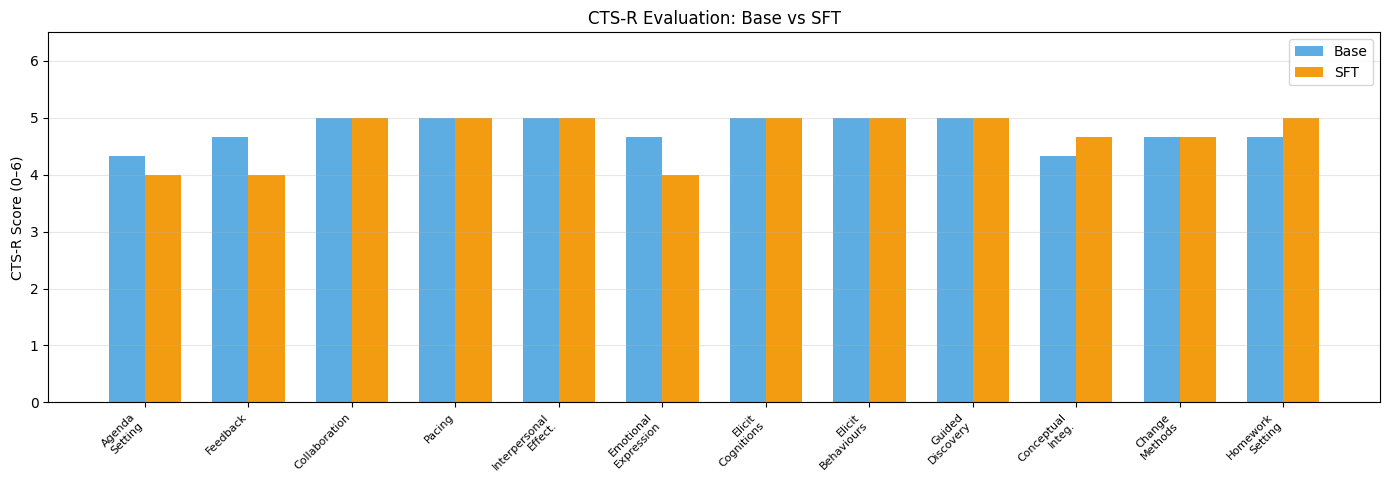

Chart saved → ../reports/ctsr_eval_chart.png


In [21]:
# ── Grouped bar chart: Base vs SFT ─────────────────────────────────────────────
base_means = scores_df[scores_df["model"] == "base"][ITEM_KEYS].mean()
sft_means  = scores_df[scores_df["model"] == "sft"][ITEM_KEYS].mean()

x = np.arange(len(ITEM_KEYS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width / 2, base_means.values, width, label="Base", color="#5dade2")
ax.bar(x + width / 2, sft_means.values,  width, label="SFT",  color="#f39c12")

ax.set_ylabel("CTS-R Score (0–6)")
ax.set_title("CTS-R Evaluation: Base vs SFT")
ax.set_xticks(x)
ax.set_xticklabels(ITEM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 6.5)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(CHART_PNG, dpi=150)
plt.show()
print(f"Chart saved → {CHART_PNG}")

In [22]:
# ── Print sample transcripts ───────────────────────────────────────────────────
for transcript in all_transcripts[:6]:  # first base + first sft
    print(f"\n{'='*60}")
    print(f"Model: {transcript['model']}  |  Vignette: {transcript['vignette']}")
    print(f"{'='*60}")
    for t in transcript["turns"]:
        tag = "🧑‍⚕️ Therapist" if t["role"] == "therapist" else "🗣️ Patient"
        print(f"\n{tag}:\n{t['content']}")


Model: base  |  Vignette: Marcus

🧑‍⚕️ Therapist:
Welcome, I'm glad you're here; to get us started, would you be open to collaboratively setting an agenda for today's session based on what feels most pressing for you right now? I want to make sure we focus on the issues that will give us the most value in our time together. 

Once we've clarified our goals, I'd like to invite you to share a bit about what brings you here and how things have been going since our last contact or since you last felt this way.

🗣️ Patient:
I guess we could start by talking about how hard it’s been just getting out of bed and that feeling like I’ve let my family down. The other thing that’s on my mind is figuring out if there’s any realistic way to get back to work at my age. I’m not sure where to begin, but those seem like the biggest things weighing on me right now.

🧑‍⚕️ Therapist:
It takes real courage to name these specific struggles, and I want to validate how heavy that burden of feeling you've let 

In [13]:
# ── Save full transcripts + scores as JSONL ───────────────────────────────────
with open(EVAL_JSONL, "w") as f:
    for transcript, score_row in zip(all_transcripts, scores_list):
        record = {
            "model":    transcript["model"],
            "vignette": transcript["vignette"],
            "turns":    transcript["turns"],
            "scores":   {
                k: {"score": score_row[k], "rationale": score_row[k + "_rationale"]}
                for k in ITEM_KEYS
            },
        }
        f.write(json.dumps(record) + "\n")

# ── Save scores table as CSV ───────────────────────────────────────────────────
scores_df.to_csv(EVAL_CSV, index=False)

print(f"Transcripts + scores → {EVAL_JSONL}  ({EVAL_JSONL.stat().st_size / 1024:.1f} KB)")
print(f"Scores CSV           → {EVAL_CSV}")
print(f"Chart                → {CHART_PNG}")

Transcripts + scores → ../reports/ctsr_eval_transcripts.jsonl  (38.9 KB)
Scores CSV           → ../reports/ctsr_eval_scores.csv
Chart                → ../reports/ctsr_eval_chart.png
